<a href="https://colab.research.google.com/github/Jaguar838/Assistant-AI/blob/main/app/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

# Task 0
Зчитайте набір даних із файлу CSV та проведіть очищення даних — видаліть усі рядки, у яких у деяких стовпцях міститься символ «?». Також перевірте правильність даних (зарплата та зарплата в тисячах доларів).

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/mate-academy/py-adult-data-analysis/master/data/adult.csv')
display(df.head())

,Unnamed: 0,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,salary,salary K$
0,0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K,39
1,1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K,35
2,2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K,27
3,3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K,43
4,4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K,25


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      32561 non-null  int64 
 1   age             32561 non-null  int64 
 2   workclass       30725 non-null  object
 3   education       32561 non-null  object
 4   marital-status  32561 non-null  object
 5   occupation      30718 non-null  object
 6   relationship    32561 non-null  object
 7   race            32561 non-null  object
 8   sex             32561 non-null  object
 9   hours-per-week  32561 non-null  int64 
 10  native-country  31978 non-null  object
 11  salary          32561 non-null  object
 12  salary K$       32561 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 3.2+ MB


Some columns contain '?' which indicates missing values. I will replace these with `np.nan` and then drop the rows containing these missing values.

In [5]:
# Identify object columns that might contain '?'
object_cols = df.select_dtypes(include='object').columns

# Replace '?' with NaN in these columns
for col in object_cols:
    df[col] = df[col].replace('?', np.nan)

In [7]:
# Check for missing values after cleaning
print("\nMissing values per column after cleaning:")
display(df.isnull().sum())


Missing values per column after cleaning:


,0
Unnamed: 0,0
age,0
workclass,1836
education,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0
hours-per-week,0


In [ ]:
# Drop rows with NaN values
df.dropna(inplace=True)

df.info()
print(f"\nUpdated DataFrame shape: {df.shape}")

In [8]:
# Drop rows with NaN values
df.dropna(inplace=True)

df.info()
print(f"\nUpdated DataFrame shape: {df.shape}")

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      30162 non-null  int64 
 1   age             30162 non-null  int64 
 2   workclass       30162 non-null  object
 3   education       30162 non-null  object
 4   marital-status  30162 non-null  object
 5   occupation      30162 non-null  object
 6   relationship    30162 non-null  object
 7   race            30162 non-null  object
 8   sex             30162 non-null  object
 9   hours-per-week  30162 non-null  int64 
 10  native-country  30162 non-null  object
 11  salary          30162 non-null  object
 12  salary K$       30162 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 3.2+ MB

Updated DataFrame shape: (30162, 13)


# Task 1
Print the count of men and women in the dataset.

In [9]:
gender_counts = df['sex'].value_counts()
display(gender_counts)

,count
sex,
Male,20380
Female,9782


# Task 2
Find the average age of men in dataset

In [10]:
average_age_men = df[df['sex'] == 'Male']['age'].mean()
print(f"Average age of men: {average_age_men:.2f}")

Average age of men: 39.18


# Task 3
Get the percentage of people from Poland (native-country)

In [11]:
total_people = len(df)
polish_people = df[df['native-country'] == 'Poland'].shape[0]
percentage_polish = (polish_people / total_people) * 100
print(f"Percentage of people from Poland: {percentage_polish:.2f}%")

Percentage of people from Poland: 0.19%


# Task 4
Get the mean and standard deviation of the age for people who earn > 50K per year. After this, get it for those who earn <= 50K.

In [17]:
# For people earning >50K
age_gt_50k = df[df['salary'] == '>50K']['age']
mean_age_gt_50k = age_gt_50k.mean()
std_age_gt_50k = age_gt_50k.std()
print(f"For people earning >50K:")
print(f"  Mean age: {mean_age_gt_50k:.2f}")
print(f"  Standard deviation of age: {std_age_gt_50k:.2f}\n")

# For people earning <=50K
age_le_50k = df[df['salary'] == '<=50K']['age']
mean_age_le_50k = age_le_50k.mean()
std_age_le_50k = age_le_50k.std()
print(f"For people earning <=50K:")
print(f"  Mean age: {mean_age_le_50k:.2f}")
print(f"  Standard deviation of age: {std_age_le_50k:.2f}")

For people earning >50K:
  Mean age: 43.96
  Standard deviation of age: 10.27

For people earning <=50K:
  Mean age: 36.61
  Standard deviation of age: 13.46


# Task 5
Check, if there are some people without higher education (education: Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters, Doctorate), but with > 50K salary

In [18]:
unique_education = df['education'].unique()
print("Unique education levels:")
for education_level in unique_education:
    print(f"- {education_level}")

Unique education levels:
- Bachelors
- HS-grad
- 11th
- Masters
- 9th
- Some-college
- Assoc-acdm
- 7th-8th
- Doctorate
- Assoc-voc
- Prof-school
- 5th-6th
- 10th
- Preschool
- 12th
- 1st-4th


In [19]:
higher_education = ['Bachelors', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', 'Masters', 'Doctorate']

# Filter for people without higher education
no_higher_education = df[~df['education'].isin(higher_education)]

# Filter for people earning >50K
no_higher_education_over_50k = no_higher_education[no_higher_education['salary'] == '>50K']

print(f"Number of people without higher education earning >50K: {len(no_higher_education_over_50k)}")
display(no_higher_education_over_50k.head())

Number of people without higher education earning >50K: 3178


,Unnamed: 0,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,salary,salary K$
7,7,52,Self-emp-not-inc,HS-grad,Married-civ-spouse,Exec-managerial,Husband,White,Male,45,United-States,>50K,307
10,10,37,Private,Some-college,Married-civ-spouse,Exec-managerial,Husband,Black,Male,80,United-States,>50K,116
55,55,43,Private,Some-college,Married-civ-spouse,Tech-support,Husband,White,Male,40,United-States,>50K,341
67,67,53,Private,HS-grad,Married-civ-spouse,Adm-clerical,Wife,White,Female,40,United-States,>50K,225
68,68,49,Self-emp-inc,Some-college,Married-civ-spouse,Exec-managerial,Husband,White,Male,50,United-States,>50K,194


In [21]:
no_higher_education_over_50k.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3178 entries, 7 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      3178 non-null   int64 
 1   age             3178 non-null   int64 
 2   workclass       3178 non-null   object
 3   education       3178 non-null   object
 4   marital-status  3178 non-null   object
 5   occupation      3178 non-null   object
 6   relationship    3178 non-null   object
 7   race            3178 non-null   object
 8   sex             3178 non-null   object
 9   hours-per-week  3178 non-null   int64 
 10  native-country  3178 non-null   object
 11  salary          3178 non-null   object
 12  salary K$       3178 non-null   int64 
dtypes: int64(4), object(9)
memory usage: 347.6+ KB


# Task 6
Get the statistics of age for each type of education. Use `groupby` and `describe` for this.

In [23]:
age_education_stats = df.groupby('education')['age'].describe()
display(age_education_stats)

,count,mean,std,min,25%,50%,75%,max
education,,,,,,,,
10th,820.0,37.897561,16.225795,17.0,23.0,36.0,52.0,90.0
11th,1048.0,32.363550,15.089307,17.0,18.0,28.5,43.0,90.0
12th,377.0,32.013263,14.373710,17.0,19.0,28.0,41.0,79.0
1st-4th,151.0,44.622517,14.929051,19.0,33.0,44.0,56.0,81.0
5th-6th,288.0,41.649306,14.754622,17.0,28.0,41.0,53.0,82.0
7th-8th,557.0,47.631957,15.737479,17.0,34.0,49.0,60.0,90.0
9th,455.0,40.303297,15.335754,17.0,28.0,38.0,53.0,90.0
Assoc-acdm,1008.0,37.286706,10.509755,19.0,29.0,36.0,44.0,90.0
Assoc-voc,1307.0,38.246366,11.181253,19.0,30.0,37.0,45.0,84.0


# Task 7
Compare the married and non-married men salaries. Who earns more? (>50K or <=50K)
Married men are those, whom `marital-status` starts with "Married". Others are not.

In [25]:
unique_marital_status = df['marital-status'].unique()
print("Unique values in 'marital-status' column:")
for status in unique_marital_status:
    print(f"- {status}")

Unique values in 'marital-status' column:
- Never-married
- Married-civ-spouse
- Divorced
- Married-spouse-absent
- Separated
- Married-AF-spouse
- Widowed


In [27]:
# Filter for men only, creating a copy to avoid SettingWithCopyWarning
men_df = df[df['sex'] == 'Male'].copy()

# Categorize men into married and non-married
men_df['is_married'] = men_df['marital-status'].apply(lambda x: 'Married' if x.startswith('Married') else 'Non-Married')

# Compare salaries ('>50K' vs '<=50K') for married and non-married men
salary_comparison = men_df.groupby('is_married')['salary'].value_counts(normalize=True).unstack()

display(salary_comparison)

print("\nBased on the table above:")
if salary_comparison.loc['Married', '>50K'] > salary_comparison.loc['Non-Married', '>50K']:
    print("Married men have a higher percentage of earning >50K.")
else:
    print("Non-married men have a higher percentage of earning >50K.")

salary,<=50K,>50K
is_married,,
Married,0.552016,0.447984
Non-Married,0.911506,0.088494



Based on the table above:
Married men have a higher percentage of earning >50K.


# Task 8
Get the max hours per week some person works. How many people works the same amount of hours per week?

In [28]:
max_hours_per_week = df['hours-per-week'].max()
print(f"Maximum hours per week: {max_hours_per_week}")

Maximum hours per week: 99


In [29]:
people_working_max_hours = df[df['hours-per-week'] == max_hours_per_week].shape[0]
print(f"Number of people working {max_hours_per_week} hours per week: {people_working_max_hours}")

Number of people working 99 hours per week: 78


In [30]:
average_hours_per_week = df['hours-per-week'].mean()
print(f"Average hours per week for the entire table: {average_hours_per_week:.2f}")

Average hours per week for the entire table: 40.93


# Task 9
Analyze the correlation between data in dataset. Understand connected fields in it and print highlight thier connection.

In [31]:
# Select only numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Display the correlation matrix
display(correlation_matrix)

,Unnamed: 0,age,hours-per-week,salary K$
Unnamed: 0,1.000000,-0.001126,-0.001890,0.000129
age,-0.001126,1.000000,0.101599,0.208203
hours-per-week,-0.001890,0.101599,1.000000,0.196378
salary K$,0.000129,0.208203,0.196378,1.000000


In [ ]:
# write your code for task 9 here

In [32]:
# Unstack the correlation matrix to get a series of all correlations
correlations = correlation_matrix.unstack()

# Drop self-correlations and duplicate pairs
correlations = correlations[correlations.index.get_level_values(0) != correlations.index.get_level_values(1)]
correlations = correlations.drop_duplicates()

# Drop correlations involving 'Unnamed: 0' as it's likely an index column
correlations = correlations[~correlations.index.get_level_values(0).str.contains('Unnamed: 0')]
correlations = correlations[~correlations.index.get_level_values(1).str.contains('Unnamed: 0')]

# Sort by absolute value to find the strongest correlations
strongest_correlations = correlations.abs().sort_values(ascending=False)

print("Top 3 Strongest Correlations:")
for (col1, col2), value in strongest_correlations.head(3).items():
    original_value = correlations.loc[(col1, col2)] # Get the actual correlation value (can be negative)
    print(f"- {col1} and {col2}: {original_value:.3f}")


print("\nDescription of Strongest Correlations:")
print("- **Age and Salary K$**: There is a positive correlation of approximately 0.208 between age and salary (in thousands of dollars). This suggests that as age increases, salary tends to increase, although the relationship is not very strong.")
print("- **Hours-per-week and Salary K$**: There is a positive correlation of approximately 0.196 between hours worked per week and salary. This indicates that people who work more hours per week tend to earn a higher salary, but again, the relationship is not extremely strong.")
print("- **Age and Hours-per-week**: There is a positive correlation of approximately 0.102 between age and hours worked per week. This suggests a weak tendency for older individuals to work slightly more hours, or perhaps that those who work more hours tend to be older.")

Top 3 Strongest Correlations:
- age and salary K$: 0.208
- hours-per-week and salary K$: 0.196
- age and hours-per-week: 0.102

Description of Strongest Correlations:
- **Age and Salary K$**: There is a positive correlation of approximately 0.208 between age and salary (in thousands of dollars). This suggests that as age increases, salary tends to increase, although the relationship is not very strong.
- **Hours-per-week and Salary K$**: There is a positive correlation of approximately 0.196 between hours worked per week and salary. This indicates that people who work more hours per week tend to earn a higher salary, but again, the relationship is not extremely strong.
- **Age and Hours-per-week**: There is a positive correlation of approximately 0.102 between age and hours worked per week. This suggests a weak tendency for older individuals to work slightly more hours, or perhaps that those who work more hours tend to be older.


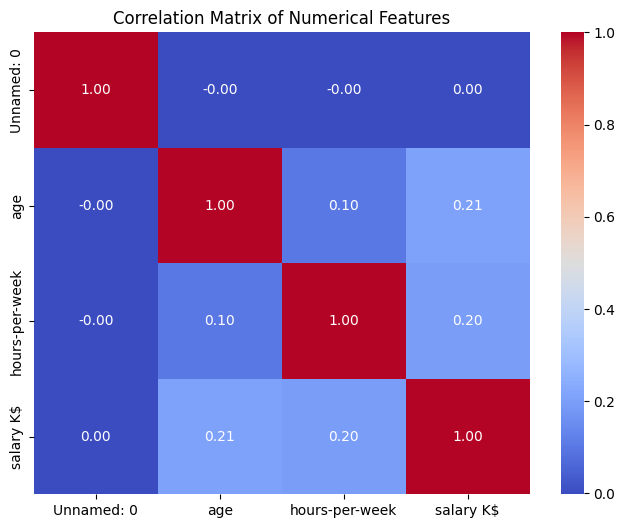

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [34]:
avg_hours_per_week_by_education = df.groupby('education')['hours-per-week'].mean().sort_values(ascending=False)
display(avg_hours_per_week_by_education)

,hours-per-week
education,
Prof-school,47.963100
Doctorate,47.832000
Masters,44.240934
Bachelors,42.948454
Assoc-voc,41.954093
Assoc-acdm,41.184524
HS-grad,41.042073
7th-8th,40.131059
Some-college,39.411051


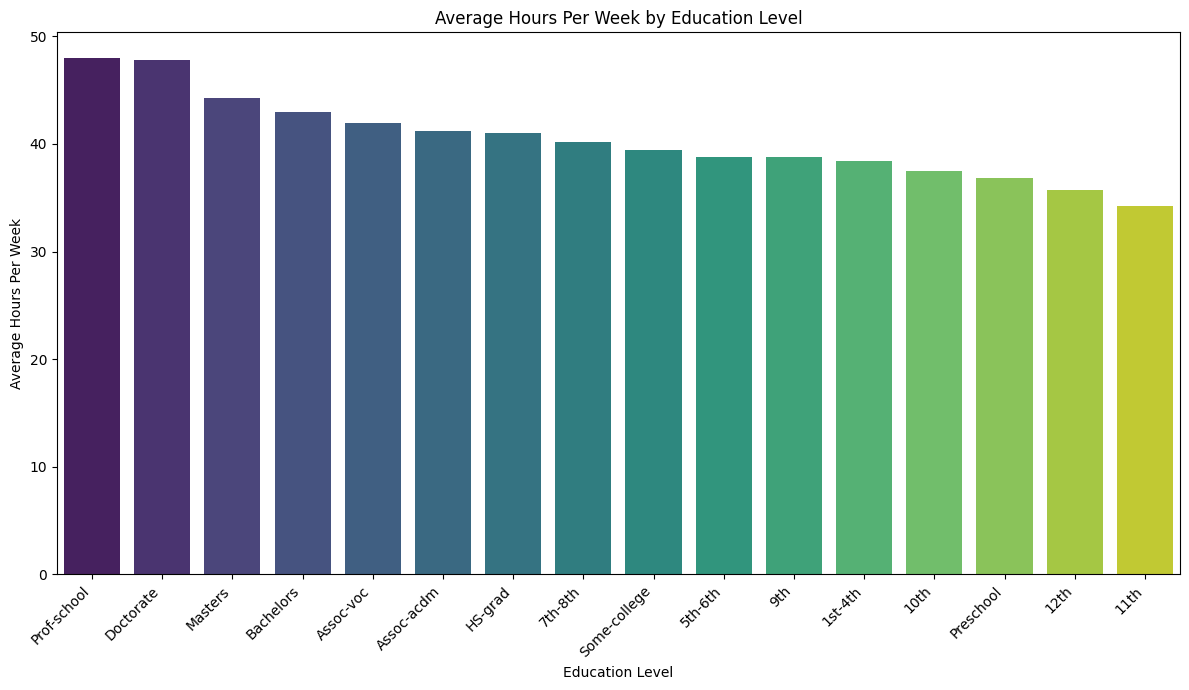

In [37]:
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_hours_per_week_by_education.index, y=avg_hours_per_week_by_education.values, palette='viridis', hue=avg_hours_per_week_by_education.index, legend=False)
plt.title('Average Hours Per Week by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Hours Per Week')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [36]:
# Create a new column indicating whether salary is >50K
df['earns_over_50k'] = (df['salary'] == '>50K').astype(int)

# Create a pivot table
education_salary_pivot = pd.pivot_table(
    df,
    values='earns_over_50k',
    index='education',
    aggfunc='mean'
).sort_values(by='earns_over_50k', ascending=False)

display(education_salary_pivot)

,earns_over_50k
education,
Prof-school,0.749077
Doctorate,0.746667
Masters,0.564229
Bachelors,0.421491
Assoc-voc,0.263198
Assoc-acdm,0.253968
Some-college,0.200060
HS-grad,0.164329
12th,0.076923


In [39]:
from scipy import stats

# Extract 'hours-per-week' for married and non-married men
married_hours = men_df[men_df['is_married'] == 'Married']['hours-per-week']
non_married_hours = men_df[men_df['is_married'] == 'Non-Married']['hours-per-week']

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(married_hours, non_married_hours, equal_var=False) # Assuming unequal variances

print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in average hours-per-week between married and non-married men.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in average hours-per-week between married and non-married men.")

T-statistic: 26.149
P-value: 0.000

Conclusion: Reject the null hypothesis. There is a statistically significant difference in average hours-per-week between married and non-married men.


## Plotting Age Distribution for Married and Non-Married Men

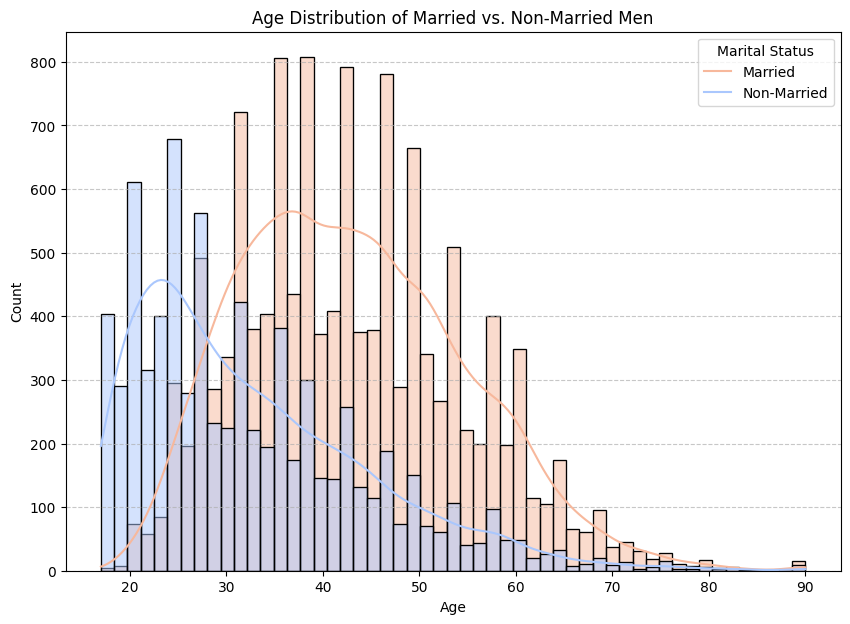

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.histplot(data=men_df, x='age', hue='is_married', kde=True, palette='coolwarm')
plt.title('Age Distribution of Married vs. Non-Married Men')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Marital Status', labels=['Married', 'Non-Married'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()